<a href="https://colab.research.google.com/github/aripenguin/Data698/blob/main/models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#libraries & keys
import requests
import pandas as pd
import numpy as np
import time
from tqdm import tqdm
from google.colab import drive
drive.mount('/content/drive')
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, cross_val_predict, train_test_split, LeaveOneOut, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

#get dataset
path = os.path.join(
    '/content/drive/MyDrive',
    'Colab Notebooks/',
    'Data 698',
    'us_movies_2021_2024_full.csv'
)

df = pd.read_csv(path)
df.columns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Index(['movie_id', 'title', 'release_date', 'popularity', 'vote_average',
       'vote_count', 'has_theatrical_release', 'providers', 'director',
       'genres', 'budget', 'main_cast', 'runtime', 'production_company_count',
       'has_major_studio', 'is_franchise', 'release_year', 'release_month',
       'is_summer_release', 'is_holiday_release', 'cast_star_power',
       'director_popularity', 'vote_density', 'log_budget', 'log_votes',
       'gt_peak', 'gt_auc', 'gt_decay', 'yt_views', 'yt_likes',
       'yt_views_density', 'yt_likes_density', 'success_bool'],
      dtype='object')

In [ ]:
# success boolean column
popularity_mean = df['popularity'].mean()
vote_count_density_mean = df['vote_density'].mean()
gt_auc_mean = df['gt_auc'].mean()
yt_views_density_mean = df['yt_views_density'].mean()

tmdb_conditions = (
    (df['popularity'] >= popularity_mean).astype(int) +
    (df['vote_density'] >= vote_count_density_mean).astype(int)
)
social_conditions = (
    (df['gt_auc'] >= gt_auc_mean).astype(int) +
    (df['yt_views_density'] >= yt_views_density_mean).astype(int)
)
df['success_bool'] = (tmdb_conditions >= 1) & (social_conditions >= 1)

print(df['success_bool'].value_counts())

final_path = os.path.join(
    '/content/drive/MyDrive',
    'Colab Notebooks/',
    'Data 698',
    'us_movies_2021_2024_full.csv'
)

#df.to_csv(final_path, index=False)

success_bool
False    1547
True      453
Name: count, dtype: int64


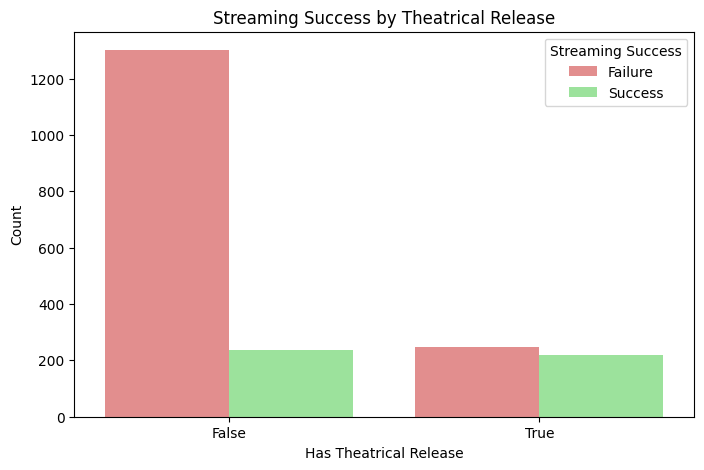

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='has_theatrical_release',
    hue='success_bool',
    palette=['lightcoral','lightgreen']
)

plt.title('Streaming Success by Theatrical Release')
plt.xlabel('Has Theatrical Release')
plt.ylabel('Count')
plt.legend(title='Streaming Success',
           labels=['Failure', 'Success'])

plt.show()

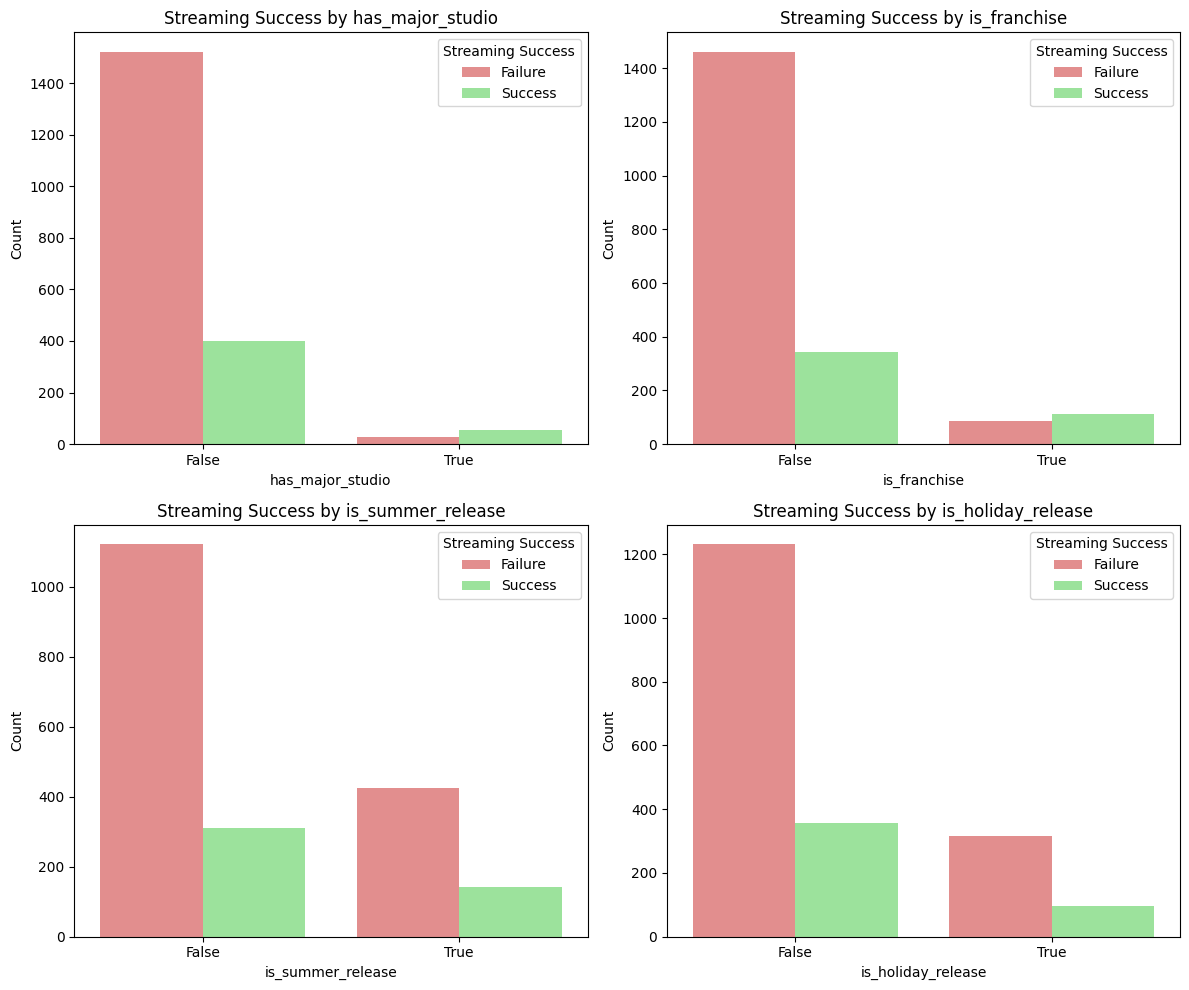

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

features = ['has_major_studio', 'is_franchise', 'is_summer_release', 'is_holiday_release']

for ax, var in zip(axes.flatten(), features):
    sns.countplot(
        data=df,
        x=var,
        hue='success_bool',
        palette=['lightcoral','lightgreen'],
        ax=ax
    )

    ax.set_title(f'Streaming Success by {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Count')

    ax.legend(
        title='Streaming Success',
        labels=['Failure', 'Success']
    )

plt.tight_layout()
plt.show()

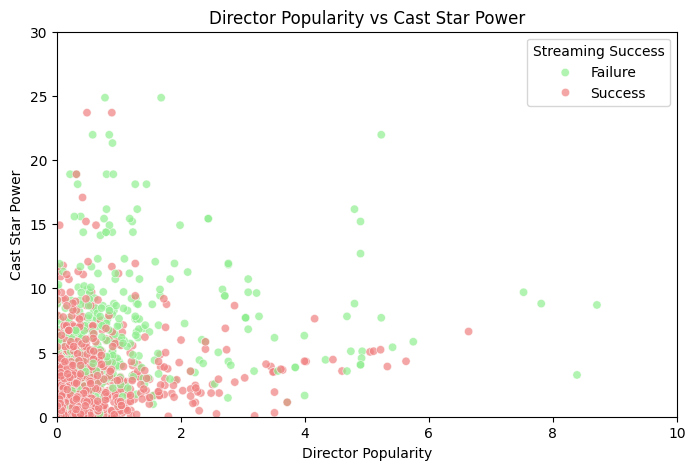

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='director_popularity',
    y='cast_star_power',
    hue='success_bool',
    palette=['lightcoral','lightgreen'],
    alpha=0.7
)

plt.title('Director Popularity vs Cast Star Power')
plt.xlabel('Director Popularity')
plt.ylabel('Cast Star Power')
plt.xlim(0, 10)
plt.ylim(0, 30)
plt.legend(title='Streaming Success',
           labels=['Failure', 'Success'])

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='director_popularity',
    y='cast_star_power',
    hue='success_bool',
    alpha=0.7
)

plt.title('Director Popularity vs Cast Star Power')
plt.xlabel('Director Popularity')
plt.ylabel('Cast Star Power')
plt.xlim(0, 10)
plt.ylim(0, 30)

plt.show()

In [ ]:
#decision tree 1: Basic production features
X = df[['providers','genres', 'budget', 'runtime','production_company_count','has_major_studio','is_franchise','release_year','release_month','is_summer_release','is_holiday_release']]
X = pd.get_dummies(X, drop_first=True) #for strings
y = df['success_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80:20
    random_state=715,
    stratify=y
)

tree_model = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=3,
    random_state=715
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

importances = tree_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    .sort_values(by='Importance', ascending=False)
)

print(feature_importance_df)

Accuracy: 0.8650


Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.97      0.92       309
        True       0.84      0.51      0.63        91

    accuracy                           0.86       400
   macro avg       0.85      0.74      0.77       400
weighted avg       0.86      0.86      0.85       400

                                     Feature  Importance
0                                     budget    0.800617
20                     providers_['Netflix']    0.083737
1                                    runtime    0.082073
14                     providers_['HBO Max']    0.017618
6                              release_month    0.015955
..                                       ...         ...
206  genres_['Comedy', 'Drama', 'Adventure']    0.000000
207     genres_['Comedy', 'Drama', 'Family']    0.000000
208    genres_['Comedy', 'Drama', 'Fantasy']    0.000000
209      genres_['Comedy', 'Drama', 'Music']    0.000000
200 

In [ ]:
#decision tree 2: Basic production features - only numerics (2.5 numerics & booleans?)
X = df[['budget', 'runtime','production_company_count','has_major_studio','is_franchise','release_year','release_month','is_summer_release','is_holiday_release']]
#X = pd.get_dummies(X, drop_first=True) #for strings
y = df['success_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80:20
    random_state=715,
    stratify=y
)

tree_model = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=3,
    random_state=715
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

importances = tree_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    .sort_values(by='Importance', ascending=False)
)

print(feature_importance_df)

Accuracy: 0.8350


Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.98      0.90       309
        True       0.84      0.34      0.48        91

    accuracy                           0.83       400
   macro avg       0.84      0.66      0.69       400
weighted avg       0.84      0.83      0.81       400

                    Feature  Importance
0                    budget    0.849834
1                   runtime    0.089580
2  production_company_count    0.043124
6             release_month    0.017462
3          has_major_studio    0.000000
4              is_franchise    0.000000
5              release_year    0.000000
7         is_summer_release    0.000000
8        is_holiday_release    0.000000


In [ ]:
#decision tree 3: Best of part 1
X = df[['providers','genres', 'budget', 'runtime','production_company_count']]
X = pd.get_dummies(X, drop_first=True) #for strings
y = df['success_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80:20
    random_state=715,
    stratify=y
)

tree_model = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=3,
    random_state=715
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

importances = tree_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    .sort_values(by='Importance', ascending=False)
)

print(feature_importance_df)

Accuracy: 0.8650


Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.97      0.92       309
        True       0.84      0.51      0.63        91

    accuracy                           0.86       400
   macro avg       0.85      0.74      0.77       400
weighted avg       0.86      0.86      0.85       400

                                             Feature  Importance
0                                             budget    0.807553
14                             providers_['Netflix']    0.084462
1                                            runtime    0.082785
8                              providers_['HBO Max']    0.017771
395                      genres_['History', 'Drama']    0.007430
..                                               ...         ...
203              genres_['Comedy', 'Drama', 'Music']    0.000000
204            genres_['Comedy', 'Drama', 'Romance']    0.000000
205                       genres_['Comedy', 'D

In [ ]:
#decision tree 4: Popularity and Engagement
X = df[['director_popularity','cast_star_power', 'vote_average','yt_likes_density']]
y = df['success_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80:20
    random_state=715,
    stratify=y
)

tree_model = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=3,
    random_state=715
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

importances = tree_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    .sort_values(by='Importance', ascending=False)
)

print(feature_importance_df)

Accuracy: 0.8975


Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.96      0.94       309
        True       0.84      0.68      0.75        91

    accuracy                           0.90       400
   macro avg       0.87      0.82      0.84       400
weighted avg       0.89      0.90      0.89       400

               Feature  Importance
3     yt_likes_density    0.823857
1      cast_star_power    0.164783
0  director_popularity    0.011360
2         vote_average    0.000000


In [ ]:
#decision tree 5: Best of part 1 & 2
X = df[['providers','genres', 'budget', 'runtime','production_company_count','director_popularity','cast_star_power', 'vote_average','yt_likes_density']]
X = pd.get_dummies(X, drop_first=True) #for strings
y = df['success_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80:20
    random_state=715,
    stratify=y
)

tree_model = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=3,
    random_state=715
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

importances = tree_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    .sort_values(by='Importance', ascending=False)
)

print(feature_importance_df)

Accuracy: 0.9000


Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.96      0.94       309
        True       0.84      0.69      0.76        91

    accuracy                           0.90       400
   macro avg       0.88      0.83      0.85       400
weighted avg       0.90      0.90      0.90       400

                                     Feature  Importance
6                           yt_likes_density    0.782054
4                            cast_star_power    0.141160
0                                     budget    0.076786
397     genres_['History', 'Drama', 'Music']    0.000000
398       genres_['History', 'Drama', 'War']    0.000000
..                                       ...         ...
204  genres_['Comedy', 'Drama', 'Adventure']    0.000000
205     genres_['Comedy', 'Drama', 'Family']    0.000000
206    genres_['Comedy', 'Drama', 'Fantasy']    0.000000
207      genres_['Comedy', 'Drama', 'Music']    0.000000
198 

In [ ]:
#decision tree 5.1: Best of part 1 & 2 condensed
X = df[['budget','cast_star_power','yt_likes_density']]
X = pd.get_dummies(X, drop_first=True) #for strings
y = df['success_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80:20
    random_state=715,
    stratify=y
)

tree_model = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=3,
    random_state=715
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

importances = tree_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    .sort_values(by='Importance', ascending=False)
)

print(feature_importance_df)

Accuracy: 0.9000


Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.96      0.94       309
        True       0.84      0.69      0.76        91

    accuracy                           0.90       400
   macro avg       0.88      0.83      0.85       400
weighted avg       0.90      0.90      0.90       400

            Feature  Importance
2  yt_likes_density    0.782054
1   cast_star_power    0.141160
0            budget    0.076786


In [ ]:
#decision tree 5.2: Best of part 1 & 2 w/ log-scaled features for vote_average
X = df[['providers','genres', 'budget', 'runtime','production_company_count','director_popularity','cast_star_power', 'log_votes','yt_likes_density']]
X = pd.get_dummies(X, drop_first=True) #for strings
y = df['success_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80:20
    random_state=715,
    stratify=y
)

tree_model = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=3,
    random_state=715
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

importances = tree_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    .sort_values(by='Importance', ascending=False)
)

print(feature_importance_df)

Accuracy: 0.9225


Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.98      0.95       309
        True       0.91      0.74      0.81        91

    accuracy                           0.92       400
   macro avg       0.92      0.86      0.88       400
weighted avg       0.92      0.92      0.92       400

                                     Feature  Importance
5                                  log_votes    0.926691
6                           yt_likes_density    0.067846
2                   production_company_count    0.005463
397     genres_['History', 'Drama', 'Music']    0.000000
398       genres_['History', 'Drama', 'War']    0.000000
..                                       ...         ...
204  genres_['Comedy', 'Drama', 'Adventure']    0.000000
205     genres_['Comedy', 'Drama', 'Family']    0.000000
206    genres_['Comedy', 'Drama', 'Fantasy']    0.000000
207      genres_['Comedy', 'Drama', 'Music']    0.000000
198 

In [ ]:
#decision tree 6: Best of part 1 & 2 plus theatrical release
X = df[['has_theatrical_release','providers','genres', 'budget', 'runtime','production_company_count','director_popularity','cast_star_power', 'log_votes','yt_likes_density']]
X = pd.get_dummies(X, drop_first=True) #for strings
y = df['success_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80:20
    random_state=715,
    stratify=y
)

tree_model = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=3,
    random_state=715
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

importances = tree_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    .sort_values(by='Importance', ascending=False)
)

print(feature_importance_df)

Accuracy: 0.9225


Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.98      0.95       309
        True       0.91      0.74      0.81        91

    accuracy                           0.92       400
   macro avg       0.92      0.86      0.88       400
weighted avg       0.92      0.92      0.92       400

                                     Feature  Importance
6                                  log_votes    0.926691
7                           yt_likes_density    0.067846
3                   production_company_count    0.005463
397    genres_['History', 'Drama', 'Action']    0.000000
398     genres_['History', 'Drama', 'Music']    0.000000
..                                       ...         ...
204         genres_['Comedy', 'Documentary']    0.000000
205  genres_['Comedy', 'Drama', 'Adventure']    0.000000
206     genres_['Comedy', 'Drama', 'Family']    0.000000
207    genres_['Comedy', 'Drama', 'Fantasy']    0.000000
198 

In [ ]:
#decision tree 7: just theatrical release
X = df['has_theatrical_release']
X = pd.get_dummies(X, drop_first=True) #for strings
y = df['success_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80:20
    random_state=715,
    stratify=y
)

tree_model = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=3,
    random_state=715
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


importances = tree_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    .sort_values(by='Importance', ascending=False)
)

print(feature_importance_df)

Accuracy: 0.7725


Classification Report:
              precision    recall  f1-score   support

       False       0.77      1.00      0.87       309
        True       0.00      0.00      0.00        91

    accuracy                           0.77       400
   macro avg       0.39      0.50      0.44       400
weighted avg       0.60      0.77      0.67       400

   Feature  Importance
0     True         1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#random forest w/ opt features from best: decision tree 6

#opt features
X = df[['providers','genres','budget','runtime','production_company_count','director_popularity','cast_star_power','log_votes','yt_likes_density']]

X = pd.get_dummies(X, drop_first=True)
y = df['success_bool']

#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=715
)

rf_model = RandomForestClassifier(
    n_estimators=100,      #trees
    criterion='gini',      #/'entropy'
    max_depth=5,
    random_state=715
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))


importances = rf_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    .sort_values(by='Importance', ascending=False)
)

print("\nFeature Importances:")
print(feature_importance_df)

Accuracy: 0.8775

Classification Report:
              precision    recall  f1-score   support

       False       0.87      1.00      0.93       314
        True       0.97      0.44      0.61        86

    accuracy                           0.88       400
   macro avg       0.92      0.72      0.77       400
weighted avg       0.89      0.88      0.86       400


Feature Importances:
                                               Feature  Importance
5                                            log_votes    0.171058
6                                     yt_likes_density    0.143764
0                                               budget    0.104888
3                                  director_popularity    0.097836
4                                      cast_star_power    0.094315
..                                                 ...         ...
307                 genres_['Drama', 'History', 'War']    0.000000
309             genres_['Drama', 'Horror', 'Thriller']    0.000000
311    

In [ ]:
#log regression w/ opt features from best: decision tree 6

#opt features
X = df[['providers','genres','budget','runtime','production_company_count','director_popularity','cast_star_power','log_votes','yt_likes_density']]

X = pd.get_dummies(X, drop_first=True)
y = df['success_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=715,
    stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


log_model = LogisticRegression(
    random_state=715,
    max_iter=1000
)

log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8775

              precision    recall  f1-score   support

       False       0.90      0.94      0.92       309
        True       0.77      0.66      0.71        91

    accuracy                           0.88       400
   macro avg       0.84      0.80      0.82       400
weighted avg       0.87      0.88      0.87       400



In [ ]:
#log reg w/ ftrl & opt features from best: decision tree 6

#opt features
X = df[['providers','genres','budget','runtime','production_company_count','director_popularity','cast_star_power','log_votes','yt_likes_density']]

X = pd.get_dummies(X, drop_first=True)
y = df['success_bool']

#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=715,
    stratify=y
)

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression(
    random_state=715,
    max_iter=1000
)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8775

              precision    recall  f1-score   support

       False       0.90      0.94      0.92       309
        True       0.77      0.66      0.71        91

    accuracy                           0.88       400
   macro avg       0.84      0.80      0.82       400
weighted avg       0.87      0.88      0.87       400



In [ ]:
#leave one out cross validation for best: decision tree 6

#opt features
X = df[['providers','genres','budget','runtime','production_company_count','director_popularity','cast_star_power','log_votes','yt_likes_density']]

X = pd.get_dummies(X, drop_first=True)
y = df['success_bool']

tree_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=715
)

loo = LeaveOneOut()

y_pred = cross_val_predict(
    tree_model,
    X,
    y,
    cv=loo,
    n_jobs=-1
)

accuracy = accuracy_score(y, y_pred)

print(f"LOOCV Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y, y_pred))

tree_model.fit(X, y)

#feature importances
importances = tree_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    .sort_values(by='Importance', ascending=False)
)

print("\nFeature Importances:")
print(feature_importance_df)



LOOCV Accuracy: 0.9055

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.97      0.94      1547
        True       0.88      0.68      0.77       453

    accuracy                           0.91      2000
   macro avg       0.89      0.83      0.85      2000
weighted avg       0.90      0.91      0.90      2000


Feature Importances:
                                               Feature  Importance
5                                            log_votes    0.953167
6                                     yt_likes_density    0.042496
166  genres_['Animation', 'Fantasy', 'Adventure', '...    0.004337
397               genres_['History', 'Drama', 'Music']    0.000000
398                 genres_['History', 'Drama', 'War']    0.000000
..                                                 ...         ...
204            genres_['Comedy', 'Drama', 'Adventure']    0.000000
205               genres_['Comedy', 'Drama', 'Family']    0.000000
2

In [ ]:
#leave one out cross validation - best: decision tree 6

#opt features
X = df[['providers','genres','budget','runtime','production_company_count','director_popularity','cast_star_power','log_votes','yt_likes_density']]

#set X and y
X = pd.get_dummies(X, drop_first=True)
y = df['success_bool']

param_grid = {
    'max_depth':[3,5,7,None],
    'min_samples_split':[2,5,10],#,5,10
    'min_samples_leaf':[1,2,5],#,2,5
    'criterion':['gini','entropy']
}

grid=GridSearchCV(
    DecisionTreeClassifier(random_state=715),
    param_grid,
    cv=LeaveOneOut(),
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X,y)

print("Best Score:", grid.best_score_)
print("Best Params:", grid.best_params_)



Best Score: 0.9155
Best Params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [ ]:
#param grid for best: decision tree 6

#opt features
X = df[['providers','genres','budget','runtime','production_company_count','director_popularity','cast_star_power','log_votes','yt_likes_density']]
X = pd.get_dummies(X, drop_first=True) #for strings
y = df['success_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80:20
    random_state=715,
    stratify=y
)

tree_model = DecisionTreeClassifier(random_state=715)

param_grid = {
    'max_depth':[2,3,5,7,None],
    'min_samples_split':[2,5,10],#,5,10
    'min_samples_leaf':[1,2,5],#,2,5
    'criterion':['gini','entropy']
}

#grid search with cross-validation on training data
grid_search = GridSearchCV(
    estimator=tree_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X,y)

grid_search.fit(X_train, y_train)
best_tree = grid_search.best_estimator_
y_pred = best_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nBest Params: {grid_search.best_params_}")
print(f"\nAccuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))



Best Params: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

Accuracy: 0.9275

Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.97      0.95       309
        True       0.90      0.77      0.83        91

    accuracy                           0.93       400
   macro avg       0.92      0.87      0.89       400
weighted avg       0.93      0.93      0.93       400



In [ ]:
#decision tree 6 with different parameter configurations

#opt features
X = df[['providers','genres','budget','runtime','production_company_count','director_popularity','cast_star_power','log_votes','yt_likes_density']]
X = pd.get_dummies(X, drop_first=True) #for strings
y = df['success_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80:20
    random_state=715,
    stratify=y
)

param_grid = {
    'max_depth':[2,3,5,7,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,5],
    'criterion':['gini','entropy']
}

results = []

for params in ParameterGrid(param_grid):
    model = DecisionTreeClassifier(
        random_state=715,
        **params
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        'params': params,
        'test_accuracy': acc
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by='test_accuracy',
    ascending=False
)


,params,test_accuracy
0,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.9275
1,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.9275
2,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.9275
3,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.9275
4,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.9275
...,...,...
83,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.8825
82,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.8825
85,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.8825
81,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.8775
